In [1]:
## IMPORTS
import numpy as np 
import matplotlib.pyplot as plt


## RK4
def kinematic_rk4(t, f, initconds, args=(), order=2):
    """
    Classical RK4 integrator for first- and second-order systems.

    Parameters
    ----------
    t : ndarray
        1D array of time points (uniform spacing assumed).

    f : callable

        If order == 2:
            f(t, r, v, *args) -> r''

        If order == 1:
            f(t, y, *args) -> y'

    initconds : list or tuple

        If order == 2:
            if 1D:
                [r(0),r'(0)]
            if ND:
                [[r_x(0),r_y(0),...],[r'_x(0),r'_y(0)],...]

        If order == 1:
            if 1D:
                [r(0)] or just r(0)
            if ndim
                [r_x(0),r_y(0),...] or [[r_x(0),r_y(0),...]]

    args : tuple or list, optional
        Extra parameters passed to f.

    order : int
        1 -> first-order system
        2 -> second-order system (default)

    Returns
    -------
    r : ndarray 
    v : ndarray
    a : ndarray

        order == 2:
            r = position
            v = velocity
            a = acceleration

        order == 1
            r  = position
            r' = vwlocity 
    """
    N = len(t)

    # ======================================================
    # SECOND ORDER SYSTEM
    # ======================================================
    if order == 2:
        
        r0, v0 = initconds

        r0 = np.atleast_1d(r0).astype(float)
        v0 = np.atleast_1d(v0).astype(float)

        dim = len(r0)

        r = np.zeros((N, dim))
        v = np.zeros((N, dim))
        a = np.zeros((N, dim))

        r[0] = r0
        v[0] = v0
        a[0] = f(t[0], r0, v0, *args)

        for i in range(N - 1):
            dt = t[i+1] - t[i]
            half_dt = dt / 2

            t_i = t[i]
            r_i = r[i]
            v_i = v[i]

            # k1
            k1_r = v_i
            k1_v = f(t_i, r_i, v_i, *args)

            # k2
            k2_r = v_i + half_dt * k1_v
            k2_v = f(t_i + half_dt,
                     r_i + half_dt * k1_r,
                     v_i + half_dt * k1_v,
                     *args)

            # k3
            k3_r = v_i + half_dt * k2_v
            k3_v = f(t_i + half_dt,
                     r_i + half_dt * k2_r,
                     v_i + half_dt * k2_v,
                     *args)

            # k4
            k4_r = v_i + dt * k3_v
            k4_v = f(t_i + dt,
                     r_i + dt * k3_r,
                     v_i + dt * k3_v,
                     *args)

            r[i+1] = r_i + dt * (k1_r + 2*k2_r + 2*k3_r + k4_r) / 6
            v[i+1] = v_i + dt * (k1_v + 2*k2_v + 2*k3_v + k4_v) / 6
            a[i+1] = f(t[i+1], r[i+1], v[i+1], *args)

        if dim == 1:
            return r[:,0], v[:,0], a[:,0]
        return r.T, v.T, a.T

    # ======================================================
    # FIRST ORDER SYSTEM
    # ======================================================
    elif order == 1:

        r0 = np.atleast_1d(initconds).astype(float)
        dim = len(r0)

        r = np.zeros((N, dim))
        v = np.zeros((N, dim))

        r[0] = r0
        v[0] = f(t[0], r0, *args)

        for i in range(N - 1):
            dt = t[i+1] - t[i]
            half_dt = dt / 2
            
            t_i = t[i]
            r_i = r[i]

            k1 = f(t_i, r_i, *args)
            k2 = f(t_i + half_dt, r_i + half_dt * k1, *args)
            k3 = f(t_i + half_dt, r_i + half_dt * k2, *args)
            k4 = f(t_i + dt, r_i + dt * k3, *args)

            r[i+1] = r_i + dt * (k1 + 2*k2 + 2*k3 + k4) / 6
            v[i+1] = f(t[i+1], r[i+1], *args)
            
        if dim == 1:
            return r[:,0], v[:,0]
        else:
            return r.T, v.T
    else:
        raise ValueError("order must be 1 or 2.")


## ELLIPSE POSITION
def conic(a, e, w =0, single = False,p=None , nu=0, resol=540, nu_min=0, nu_max=2*np.pi):
    theta = np.nan
    nu_inf = np.acos(-1/e) if e > 1 else None
    if single:
        if e > 1 and abs(nu) > nu_inf:
            print(f"BEYOND ORBIT ASYMPTOTE : {np.rad2deg(nu_inf)}")
            return [np.nan, np.nan]
        theta = nu
    else:
        if e > 1:
            nu_min = -nu_inf + 0.001
            nu_max = nu_inf - 0.001
        theta = np.linspace(nu_min, nu_max, resol)
    # Determine p (semi-latus rectum)
    if p is None:
        if e == 1:
            raise ValueError("For parabola (e=1), you must provide p explicitly (a is infinite)")
        p = a * (1 - e**2)
    r = p / (1 + e * np.cos(theta))
    r = r * np.array([np.cos(theta + w), 
                      np.sin(theta + w)
                    ])
    return r

## ELLIPSE VELOCITY
def obt_vel(mu,a, e, w = 0,single=False, p=None,nu=0, resol=540, nu_min=0, nu_max=2*np.pi):
    nu_inf = np.acos(-1/e) if e > 1 else None
    if single:
        if e > 1 and abs(nu) > nu_inf:
            print(f"BEYOND ORBIT ASYMPTOTE : {np.rad2deg(nu_inf)}")
            return [np.nan, np.nan]
        theta = nu
    else:
        if e > 1:
            nu_min = -nu_inf + 0.001
            nu_max = nu_inf - 0.001
        theta = np.linspace(nu_min, nu_max, resol)

    # Determine p (semi-latus rectum)
    if p is None:
        if a is None:
            raise ValueError("Either p or a must be provided")
        if e == 1:
            raise ValueError("For parabola (e=1), you must provide p explicitly (a is infinite)")
        p = a * (1 - e**2)
    # Velocity vector using simplified form
    v = np.sqrt(mu / p) * np.array([
        -np.sin(theta + w) - e * np.sin(w),
         np.cos(theta + w) + e * np.cos(w)
    ])
    
    return v

## UNIVERSAL VARIABLES FORMULATION LAMBERT SOLVER
def lambert_solver(
    r1,
    r2,
    tof,
    mu,
    t_m,
    psi = 0,
    psi_u = 4*np.pi**2,
    psi_l =  - 4*np.pi,
    max_iter = 1000,
    tol = 1e-12
    ):

    def c_2(z):
        if z > 0:
            return (1 - np.cos(np.sqrt(z))) / z
        if z < 0:
            return (1 - np.cosh(-z)) / -z
        else:
            return 1/2
    
    def c_3(z):
        if z > 0:
            return (np.sqrt(z) - np.sin(np.sqrt(z))) / np.sqrt(z)**3
        if z < 0:
            return (np.sinh(np.sqrt(-z)) - np.sqrt(-z)) / np.sqrt(-z)**3
        else:
            return 1/6

    mag_r1 = np.linalg.norm(r1)
    mag_r2 = np.linalg.norm(r2)
    gamma  = np.dot(r1, r2) / (mag_r1 * mag_r2)
    A      = t_m * np.sqrt( mag_r1 * mag_r2 * (1 + gamma))

    B    = 0
    chi3 = 0
    tof_ = 0

    if A == 0:
        print("Orbit cannot exist")
        return [np.array([0,0,0]),np.array([0,0,0])]

    c2 = 0.5
    c3 = 1/6
    solved = False

    for i in range(max_iter):
        B = mag_r1 + mag_r2 + A * (psi * c3 - 1)/np.sqrt(c2)

        if (A > 0) and (B < 0):
            psi_l = psi_l + np.pi 
        
        chi3 = (B / c2) ** 1.5
        tof_ = (chi3 * c3 + A * np.sqrt(B))/np.sqrt(mu)

        if np.abs(tof_ - tof):
            solved = True 
            break

        if tof_ < tof:
            psi_l = psi 
        else:
            psi_u = psi
        
        psi = (psi_u + psi_l) / 2
        c2 = c_2(psi)
        c3 = c_3(psi)
        
    if not solved:
        print("Did not converge")
        return [np.array([0,0,0]),np.array([0,0,0])]
    
    f = 1 - B / mag_r1
    g = A * np.sqrt(B / mu)
    g_dot = 1 - B / mag_r2 
    f_dot = (f * g_dot - 1) / g

    v1 = (r2 - f * r1) / g
    v2 = f_dot * r1 + g_dot * v1
    return v1,v2

## TIME FROM NOW - 1 ORBIT OF TGT BODY
## ARRIVAL TIME - 1 ORBIT OF TGT BODY
mu = 1

[[ 0.52337289 -0.38785804]
 [ 0.90650844  1.66831012]]
[[0.         0.52337289]
 [0.         0.90650844]]


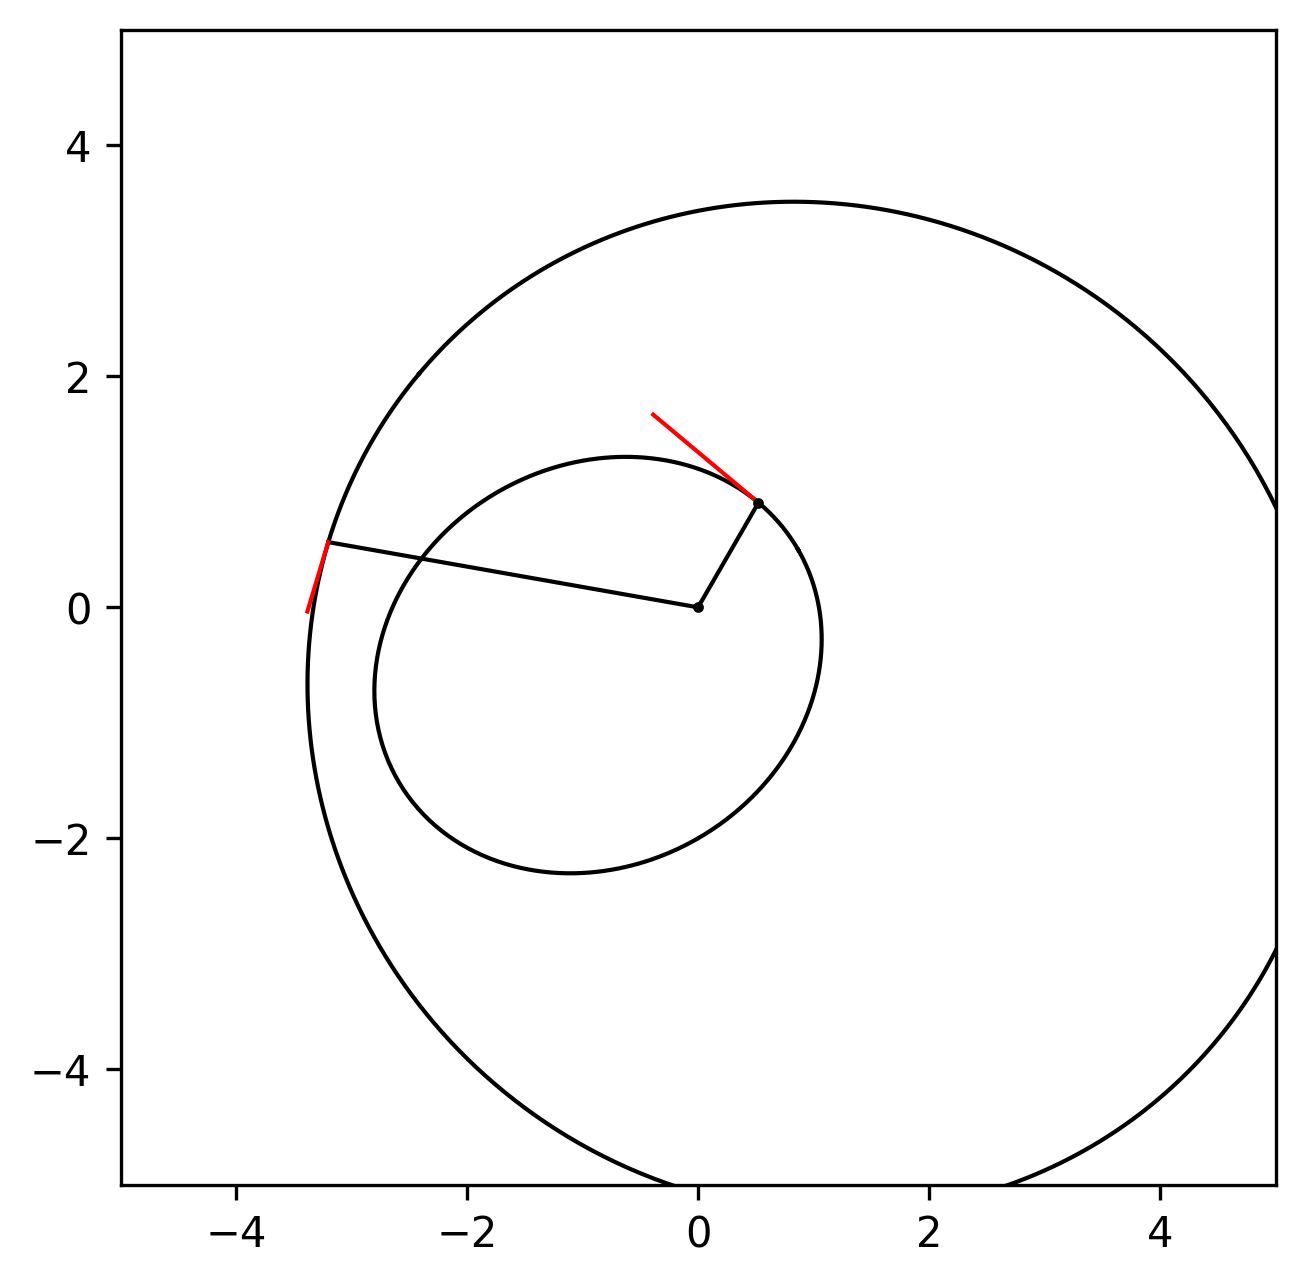

In [35]:
nu = np.deg2rad(30)
p0 = np.array([0.0,0.0])

a2 = 2
e1 = 0.5
w1 = np.deg2rad(30)

obt1 = conic(a1,e1,w1)
r1 = conic(a1,e1,w1,single=True,nu=nu)
v1 = obt_vel(mu,a1,e1,w1,single=True,nu=nu)
r1v = np.vstack([p0,r1]).T
v1v = np.vstack([r1,r1+v1]).T

a2 =4.5
e2 = 0.3
w2 = np.deg2rad(140)

obt2 = conic(a2,e2,w2)
r2 = conic(a2,e2,w2,single=True,nu=nu)
v2 = obt_vel(mu,a2,e2,w2,single=True,nu=nu)
r2v = np.vstack([p0,r2]).T
v2v = np.vstack([r2,r2+v2]).T

t = np.linspace(0,10,1000)
def facc(r):
    rmag = np.linalg.norm(r)
    if rmag == 0:
        return np.array([0,0])
    acc = - (mu / rmag**2) * r
    return acc

print(v1v)
print(r1v)
plt.figure(figsize = (5,5),dpi = 300)

plt.plot(obt1[0],obt1[1],'k-',lw=1)
plt.plot(r1v[0],r1v[1],'k-',lw=1)
plt.plot(v1v[0],v1v[1],'r-',lw=1)

plt.plot(obt2[0],obt2[1],'k-',lw=1)
plt.plot(r2v[0],r2v[1],'k-',lw=1)
plt.plot(v2v[0],v2v[1],'r-',lw=1)

plt.scatter(0,0,color='k',s=2.5)
plt.scatter(r1[0],r1[1],color='k',s=2.5,zorder =5)
sq = 5
plt.xlim(-sq,sq)
plt.ylim(-sq,sq)
plt.gca().set_aspect("equal")
plt.show()